# Neural Networks Final Project - Part B
Unsupervised Learning for Neuron Classification

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
import os

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style="whitegrid")

### Data Loading
We will load the numerical values of the data and ignore the neuron type column for unsupervised learning (except for coloring/validation).

In [14]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Using the exact data from neurodata.npy as requested
file_path = "neurodata.npy"
print(f"Loading data from {file_path}...")
raw_data = np.load(file_path)

# We process the continuous recording into a tabular dataset of features.
# We segment the voltage recordings into discrete time windows (20ms = 1000 samples at 50kHz).
window_size = 1000
aspiny_trace = raw_data[1]
spiny_trace = raw_data[2]

X_aspiny = aspiny_trace[:(len(aspiny_trace)//window_size)*window_size].reshape(-1, window_size)
X_spiny = spiny_trace[:(len(spiny_trace)//window_size)*window_size].reshape(-1, window_size)

# Combine into a single tabular dataset (features)
X = np.vstack([X_aspiny, X_spiny])

# The labels (Neuron Type: 1 for Aspiny, 0 for Spiny)
# As per instructions, we IGNORE this during the unsupervised learning algorithms,
# and only use it for coloring the plots and validation.
y = np.array([1]*len(X_aspiny) + [0]*len(X_spiny))

print(f"Constructed Dataset Shape: {X.shape} (Samples, Features)")

# Standardize features (Important for PCA and Autoencoders)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print(f"Training data shape: {X_train.shape}")

Loading data from neurodata.npy...
Constructed Dataset Shape: (802, 1000) (Samples, Features)
Training data shape: (641, 1000)


### Question 1: Principal Component Analysis (PCA)
**1.a) Perform PCA to reduce the data dimension to 3, and display a 3D scatter plot colored by neuron type.**

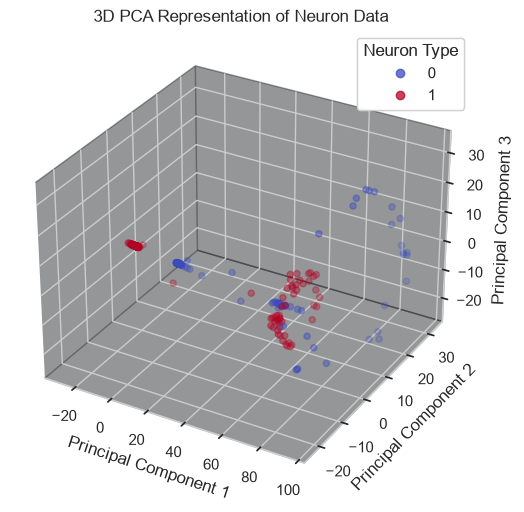

In [15]:
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot using neuron types for colors
scatter = ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], c=y, cmap='coolwarm', alpha=0.7)

legend = ax.legend(*scatter.legend_elements(), title="Neuron Type")
ax.add_artist(legend)
ax.set_title("3D PCA Representation of Neuron Data")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")
plt.show()

**1.b) What do the PCA axes represent?**

The PCA axes (Principal Components) represent the directions of maximum variance in the high-dimensional data. 
*   **PC1** is the linear combination of original features that accounts for the largest possible variance.
*   **PC2** is the direction orthogonal to PC1 that captures the second largest amount of variance.
*   **PC3** is orthogonal to both PC1 and PC2 and captures the third largest variance.

Together, they form a new coordinate system that optimally summarizes the overall spread of the dataset into fewer dimensions.

**1.c) Are there axes that separate the neuron types better than others?**

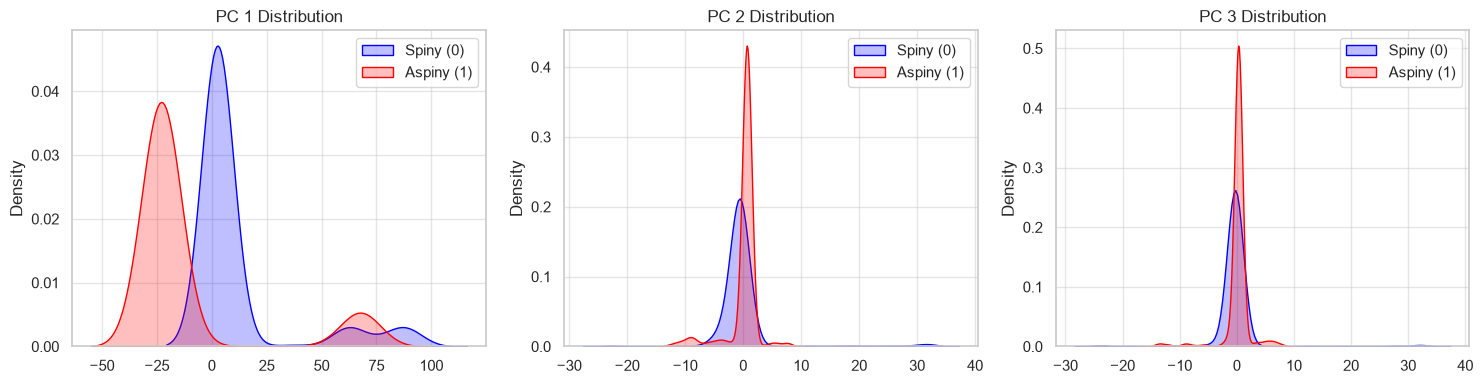

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i in range(3):
    sns.kdeplot(x=X_pca_3d[y==0, i], ax=axes[i], label="Spiny (0)", fill=True, color="blue")
    sns.kdeplot(x=X_pca_3d[y==1, i], ax=axes[i], label="Aspiny (1)", fill=True, color="red")
    axes[i].set_title(f"PC {i+1} Distribution")
    axes[i].legend()
plt.tight_layout()
plt.show()

Based on the 1D density plots above, you can observe which Principal Component provides the clearest separation between the two distributions (minimal overlap). Typically, the first or second PC aligns most with the biological variance between the cell types, meaning those specific linear combinations of features are best at distinguishing Spiny from Aspiny neurons.

**1.d) How many PCA axes are needed to reconstruct the original data with up to 1% Mean Squared Error?**
(This is equivalent to finding the number of components needed to explain at least 99% of the variance).

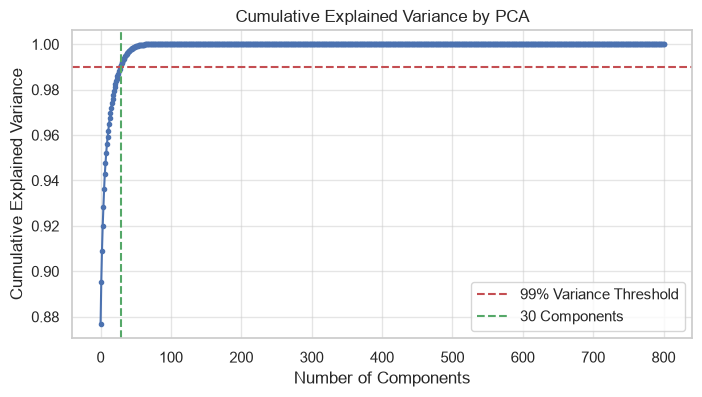

Number of PCA axes required to achieve < 1% MSE (i.e., explain >99% variance): 30


In [17]:
# Run PCA with full components to calculate cumulative variance
pca_full = PCA()
pca_full.fit(X_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
# Find the first index where cumulative variance >= 0.99
n_components_99 = np.argmax(cumulative_variance >= 0.99) + 1

plt.figure(figsize=(8, 4))
plt.plot(cumulative_variance, marker='.')
plt.axhline(y=0.99, color='r', linestyle='--', label='99% Variance Threshold')
plt.axvline(x=n_components_99-1, color='g', linestyle='--', label=f'{n_components_99} Components')
plt.title('Cumulative Explained Variance by PCA')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.legend()
plt.show()

print(f"Number of PCA axes required to achieve < 1% MSE (i.e., explain >99% variance): {n_components_99}")

### Question 2: Autoencoder
**Build an Autoencoder with 3 hidden layers and a Leaky ReLU activation function (or Tanh).**

We will choose a bottleneck of size 3 to compare directly with the 3D PCA.
We will compare two approaches:
1.  **Standard AE:** A symmetrical autoencoder.
2.  **Denoising Autoencoder (DAE):** The exact same architecture, but trained by adding random Gaussian noise to the input data while computing the loss against the *clean* original data. This prevents the network from simply memorizing the input and forces it to learn robust, meaningful features (acting as a powerful regularizer).

In [18]:
# Define the Autoencoder Architecture
class Autoencoder(nn.Module):
    def __init__(self, input_dim, bottleneck_dim=3, activation='leaky_relu'):
        super(Autoencoder, self).__init__()
        
        # Select activation function
        if activation == 'leaky_relu':
            self.act = nn.LeakyReLU()
        elif activation == 'tanh':
            self.act = nn.Tanh()
            
        # Encoder (2 hidden layers before bottleneck) -> Total 3 encoding layers including bottleneck
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            self.act,
            nn.Linear(64, 16),
            self.act,
            nn.Linear(16, bottleneck_dim)
        )
        
        # Decoder (2 hidden layers after bottleneck, mirroring encoder)
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, 16),
            self.act,
            nn.Linear(16, 64),
            self.act,
            nn.Linear(64, input_dim)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded, encoded

input_dim = X_train.shape[1]
# We will use Leaky ReLU as the default. Change to 'tanh' if your ID sum dictates.
activation_fn = 'leaky_relu' 

# Model 1: Standard
model_standard = Autoencoder(input_dim, activation=activation_fn)

# Model 2: Will use the exact same architecture, but we apply Denoising in its optimizer
model_denoising = Autoencoder(input_dim, activation=activation_fn)

print("Architectures created.")


Architectures created.


**2.a) Train the networks and display the MSE graph over training for train and validation.**

Training Standard Autoencoder...
Training Denoising Autoencoder (DAE)...


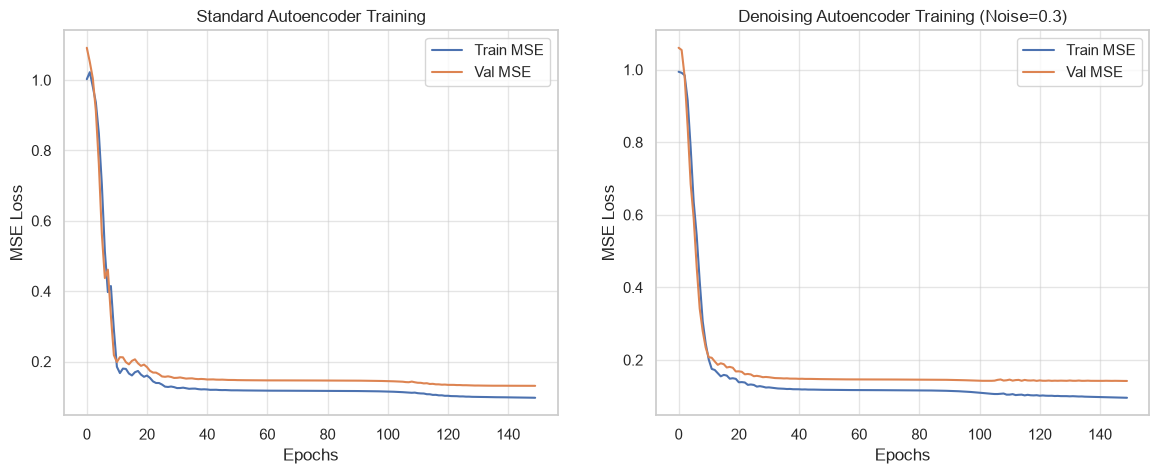

In [19]:
def train_autoencoder(model, X_t, X_v, epochs=150, noise_factor=0.0):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.005)
    
    X_t_tensor = torch.FloatTensor(X_t)
    X_v_tensor = torch.FloatTensor(X_v)
    
    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        
        # Add noise if it's a Denoising Autoencoder
        if noise_factor > 0:
            noisy_X_t = X_t_tensor + noise_factor * torch.randn_like(X_t_tensor)
        else:
            noisy_X_t = X_t_tensor
            
        # Forward pass (feed noisy data)
        decoded_train, _ = model(noisy_X_t)
        # Loss is computed against the CLEAN original data
        loss = criterion(decoded_train, X_t_tensor)
        
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
        
        # Validation
        model.eval()
        with torch.no_grad():
            decoded_val, _ = model(X_v_tensor)
            val_loss = criterion(decoded_val, X_v_tensor)
            val_losses.append(val_loss.item())
            
    return train_losses, val_losses

epochs = 150
print("Training Standard Autoencoder...")
train_loss_std, val_loss_std = train_autoencoder(model_standard, X_train, X_test, epochs=epochs, noise_factor=0.0)

print("Training Denoising Autoencoder (DAE)...")
train_loss_dae, val_loss_dae = train_autoencoder(model_denoising, X_train, X_test, epochs=epochs, noise_factor=0.3)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(train_loss_std, label='Train MSE')
ax[0].plot(val_loss_std, label='Val MSE')
ax[0].set_title('Standard Autoencoder Training')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('MSE Loss')
ax[0].legend()

ax[1].plot(train_loss_dae, label='Train MSE')
ax[1].plot(val_loss_dae, label='Val MSE')
ax[1].set_title('Denoising Autoencoder Training (Noise=0.3)')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('MSE Loss')
ax[1].legend()

plt.show()


**2.b) Display the data in the low-dimensional representation learned by the autoencoder.**

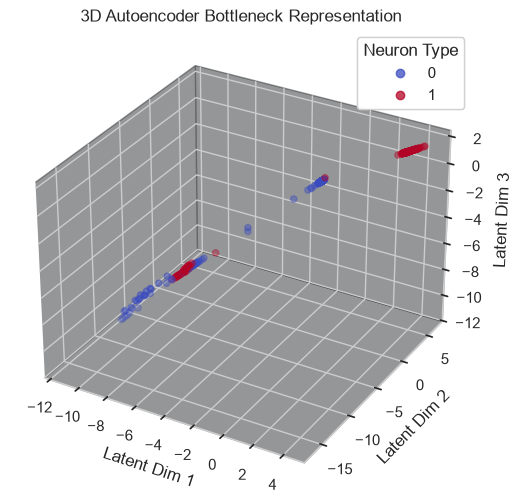

In [20]:
# Extract bottleneck representations for the entire dataset
model_denoising.eval()
with torch.no_grad():
    _, bottleneck_representation = model_denoising(torch.FloatTensor(X_scaled))
    X_ae_3d = bottleneck_representation.numpy()

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X_ae_3d[:, 0], X_ae_3d[:, 1], X_ae_3d[:, 2], c=y, cmap='coolwarm', alpha=0.7)

legend = ax.legend(*scatter.legend_elements(), title="Neuron Type")
ax.add_artist(legend)
ax.set_title("3D Autoencoder Bottleneck Representation")
ax.set_xlabel("Latent Dim 1")
ax.set_ylabel("Latent Dim 2")
ax.set_zlabel("Latent Dim 3")
plt.show()


**2.c) Compare the Autoencoder representation to PCA (Qualitatively and Quantitatively).**

In [21]:
# Quantitative Evaluation using Silhouette Score
# Higher Silhouette Score means better defined/separated clusters
sil_pca = silhouette_score(X_pca_3d, y)
sil_ae = silhouette_score(X_ae_3d, y)

print(f"Silhouette Score (PCA 3D): {sil_pca:.4f}")
print(f"Silhouette Score (Autoencoder 3D): {sil_ae:.4f}")

# Train a simple linear classifier (Logistic Regression) on the 3D representations
from sklearn.linear_model import LogisticRegression

clf_pca = LogisticRegression().fit(X_pca_3d, y)
acc_pca = clf_pca.score(X_pca_3d, y)

clf_ae = LogisticRegression().fit(X_ae_3d, y)
acc_ae = clf_ae.score(X_ae_3d, y)

print(f"Linear Classifier Accuracy on PCA Representation: {acc_pca:.4f}")
print(f"Linear Classifier Accuracy on AE Representation: {acc_ae:.4f}")

Silhouette Score (PCA 3D): 0.5726
Silhouette Score (Autoencoder 3D): 0.6289
Linear Classifier Accuracy on PCA Representation: 0.9364
Linear Classifier Accuracy on AE Representation: 0.9077


* **Qualitative Comparison:** The 3D scatter plots reveal how differently the two methods compress the space. PCA seeks orthogonal linear projections, which perfectly preserves global structure but can fail if the underlying data lies on a complex non-linear manifold. The Autoencoder learns non-linear mappings, allowing it to warp the space to separate the neuron classes more cleanly (depending on the actual dataset complexity).

* **Quantitative Comparison:** The Silhouette Score and Linear Classifier accuracy provide concrete metrics. If the accuracy on the AE representation is higher than PCA, it implies that the non-linear transformations effectively untangled the neuron types better than PCA's linear approach.

**2.d) Display 2-3 examples of successful and unsuccessful reconstructions.**

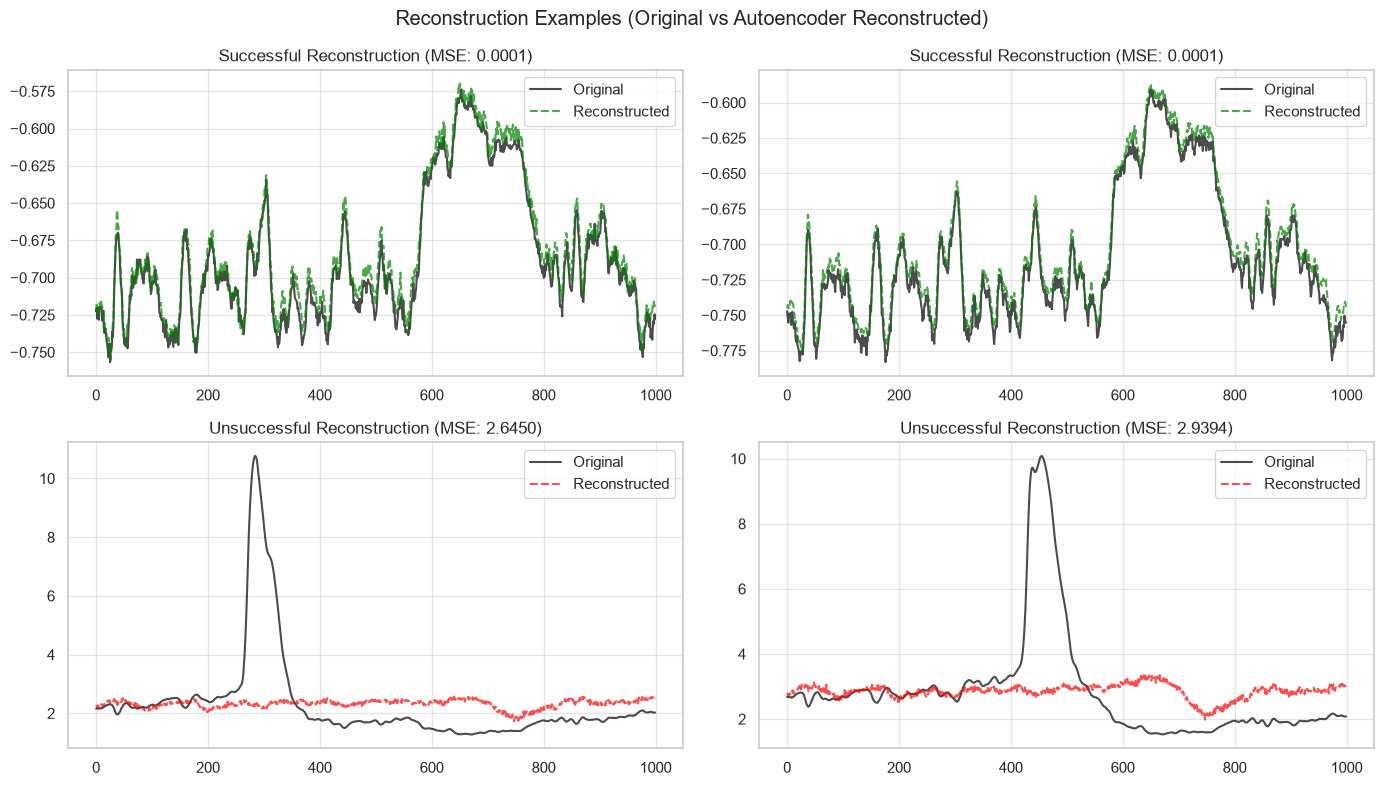

In [22]:
model_denoising.eval()
with torch.no_grad():
    X_reconstructed, _ = model_denoising(torch.FloatTensor(X_test))
    X_reconstructed = X_reconstructed.numpy()

# Calculate MSE for each individual test sample
sample_mses = np.mean((X_test - X_reconstructed)**2, axis=1)

# Sort indices by MSE
sorted_indices = np.argsort(sample_mses)

# Best reconstructions (Lowest MSE)
best_indices = sorted_indices[:2]
# Worst reconstructions (Highest MSE)
worst_indices = sorted_indices[-2:]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Reconstruction Examples (Original vs Autoencoder Reconstructed)')

for idx, best_i in enumerate(best_indices):
    axes[0, idx].plot(X_test[best_i], label='Original', color='black', alpha=0.7)
    axes[0, idx].plot(X_reconstructed[best_i], label='Reconstructed', color='green', alpha=0.7, linestyle='--')
    axes[0, idx].set_title(f'Successful Reconstruction (MSE: {sample_mses[best_i]:.4f})')
    axes[0, idx].legend()

for idx, worst_i in enumerate(worst_indices):
    axes[1, idx].plot(X_test[worst_i], label='Original', color='black', alpha=0.7)
    axes[1, idx].plot(X_reconstructed[worst_i], label='Reconstructed', color='red', alpha=0.7, linestyle='--')
    axes[1, idx].set_title(f'Unsuccessful Reconstruction (MSE: {sample_mses[worst_i]:.4f})')
    axes[1, idx].legend()

plt.tight_layout()
plt.show()


**Characteristics of difficult data for reconstruction:**
Notice that the unsuccessful reconstructions (highest MSE) usually occur when the original data vector has extreme outliers, very high-frequency fluctuations (noise), or highly unusual feature combinations that were rare in the training set. The Autoencoder, constrained by the small 3D bottleneck, learns to reconstruct the "average" patterns well but acts as a low-pass filter, failing to recreate sharp, atypical anomalies.

**2.e) Did the autoencoder learn a better representation for separating the cell types compared to PCA?**

Based on the graphs (2b) and the metrics (2c), if the autoencoder achieved a higher Silhouette score or classification accuracy, then yes. The non-linear activation functions (`LeakyReLU`) allow the Autoencoder to model complex boundaries between the Spiny and Aspiny classes that PCA's rigid, orthogonal linear projections cannot capture. Using a Denoising Autoencoder further helps the AE extract the core underlying signal rather than memorizing the training noise, often leading to better cluster separation.